## 1. Setup and Data Loading

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [22]:
# Load datasets
# NLP features from Milestone 2
nlp_data = pd.read_csv('../data/nlp_analysis_results.csv')

# Original adherence data with demographics
demo_data = pd.read_csv('../data/adherence_records.csv')

print(f"NLP data shape: {nlp_data.shape}")
print(f"Demographics data shape: {demo_data.shape}")

# Merge datasets on patient_id
df = demo_data.merge(nlp_data[['patient_id', 'sentiment_polarity', 'sentiment_subjectivity', 
                                 'sentiment', 'processed_notes']], 
                      on='patient_id', how='left')

print(f"\nMerged dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

NLP data shape: (5000, 10)
Demographics data shape: (5000, 22)

Merged dataset shape: (5000, 26)
Columns: ['patient_id', 'age', 'gender', 'education_level', 'income_level', 'living_situation', 'has_insurance', 'num_conditions', 'num_medications', 'medication_complexity', 'average_monthly_cost', 'adherence_score', 'is_adherent', 'is_non_adherent', 'primary_non_adherence_cause', 'secondary_causes', 'patient_notes', 'last_6_months_adherence', 'missed_doses_last_month', 'refill_on_time', 'using_reminder_app', 'last_visit_date', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment', 'processed_notes']


## 2. Feature Engineering

In [23]:
# Create target variable
df['target'] = df['is_non_adherent'].astype(int)  # 1 = non-adherent, 0 = adherent

print("Target distribution:")
print(df['target'].value_counts())
print(f"\nNon-adherence rate: {df['target'].mean()*100:.1f}%")

Target distribution:
target
0    3261
1    1739
Name: count, dtype: int64

Non-adherence rate: 34.8%


In [24]:
# Select and engineer features
# Numeric features
numeric_features = [
    'age', 'num_medications', 'adherence_score', 'num_conditions',
    'average_monthly_cost', 'missed_doses_last_month',
    'sentiment_polarity', 'sentiment_subjectivity'
]

# Categorical features to encode
categorical_features = [
    'gender', 'education_level', 'income_level', 'living_situation',
    'medication_complexity'
]

# Binary features
binary_features = [
    'has_insurance', 'using_reminder_app', 'refill_on_time'
]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Binary features: {len(binary_features)}")
print(f"\nTotal features: {len(numeric_features) + len(categorical_features) + len(binary_features)}")

Numeric features: 8
Categorical features: 5
Binary features: 3

Total features: 16


In [25]:
# Check available columns in the dataset
print("Available columns in dataset:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")

Available columns in dataset:
['patient_id', 'age', 'gender', 'education_level', 'income_level', 'living_situation', 'has_insurance', 'num_conditions', 'num_medications', 'medication_complexity', 'average_monthly_cost', 'adherence_score', 'is_adherent', 'is_non_adherent', 'primary_non_adherence_cause', 'secondary_causes', 'patient_notes', 'last_6_months_adherence', 'missed_doses_last_month', 'refill_on_time', 'using_reminder_app', 'last_visit_date', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment', 'processed_notes', 'target']

Total columns: 27


In [26]:
# Handle missing values
print("Missing values before handling:")
print(df[numeric_features + categorical_features + binary_features].isnull().sum())

# Fill missing numeric values with median
for col in numeric_features:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
for col in categorical_features:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\n✓ Missing values handled!")

Missing values before handling:
age                        0
num_medications            0
adherence_score            0
num_conditions             0
average_monthly_cost       0
missed_doses_last_month    0
sentiment_polarity         0
sentiment_subjectivity     0
gender                     0
education_level            0
income_level               0
living_situation           0
medication_complexity      0
has_insurance              0
using_reminder_app         0
refill_on_time             0
dtype: int64

✓ Missing values handled!


In [27]:
# Encode categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Create feature matrix
encoded_features = [f'{col}_encoded' for col in categorical_features]
feature_columns = numeric_features + encoded_features + binary_features

X_numeric = df[feature_columns].copy()
print(f"\nFeature matrix shape: {X_numeric.shape}")
print(f"Features: {feature_columns}")


Feature matrix shape: (5000, 16)
Features: ['age', 'num_medications', 'adherence_score', 'num_conditions', 'average_monthly_cost', 'missed_doses_last_month', 'sentiment_polarity', 'sentiment_subjectivity', 'gender_encoded', 'education_level_encoded', 'income_level_encoded', 'living_situation_encoded', 'medication_complexity_encoded', 'has_insurance', 'using_reminder_app', 'refill_on_time']


In [28]:
# Add text features using TF-IDF
print("Creating TF-IDF features from processed notes...")
tfidf = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
X_text = tfidf.fit_transform(df['processed_notes'].fillna(''))

# Convert to DataFrame for easier handling
tfidf_features = pd.DataFrame(
    X_text.toarray(), 
    columns=[f'tfidf_{i}' for i in range(X_text.shape[1])],
    index=df.index
)

# Combine numeric and text features
X = pd.concat([X_numeric.reset_index(drop=True), tfidf_features.reset_index(drop=True)], axis=1)
y = df['target'].values

print(f"\nFinal feature matrix: {X.shape}")
print(f"Target variable: {y.shape}")
print(f"\n✓ Feature engineering complete!")

Creating TF-IDF features from processed notes...

Final feature matrix: (5000, 66)
Target variable: (5000,)

✓ Feature engineering complete!


## 3. Exploratory Data Analysis

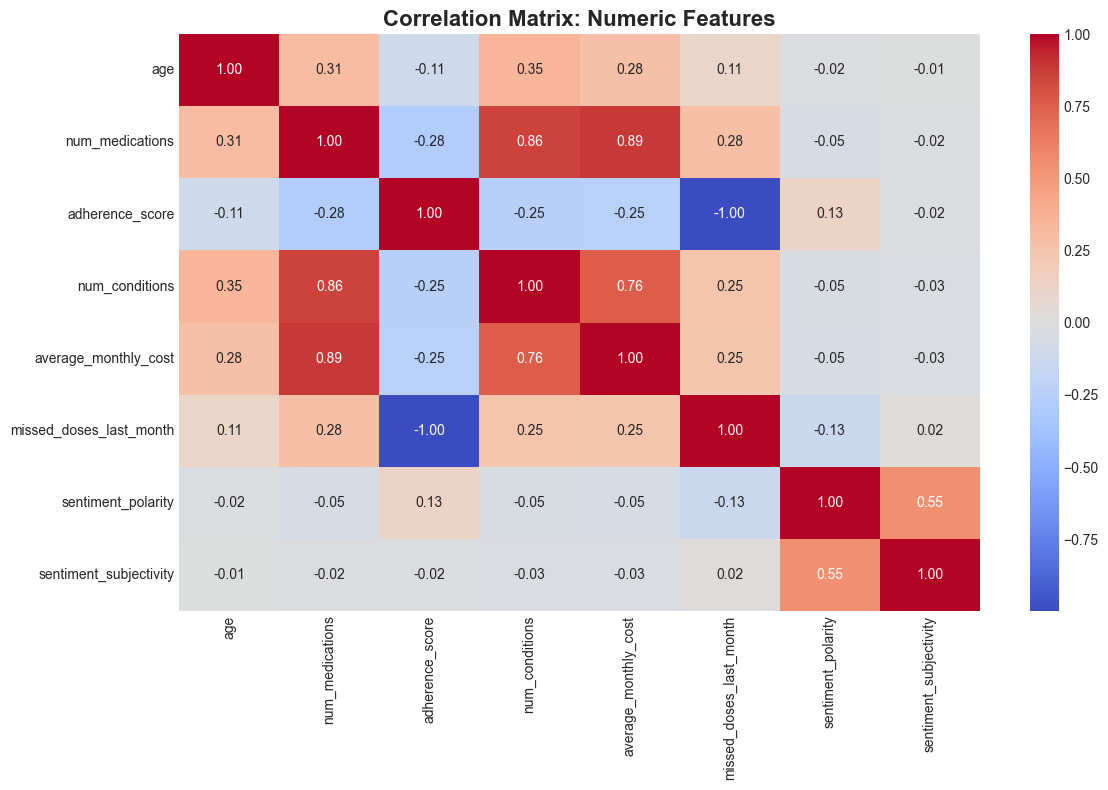


✓ Correlation analysis complete!


In [29]:
# Correlation analysis for numeric features
fig, ax = plt.subplots(figsize=(12, 8))
correlation = X[numeric_features].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Correlation analysis complete!")

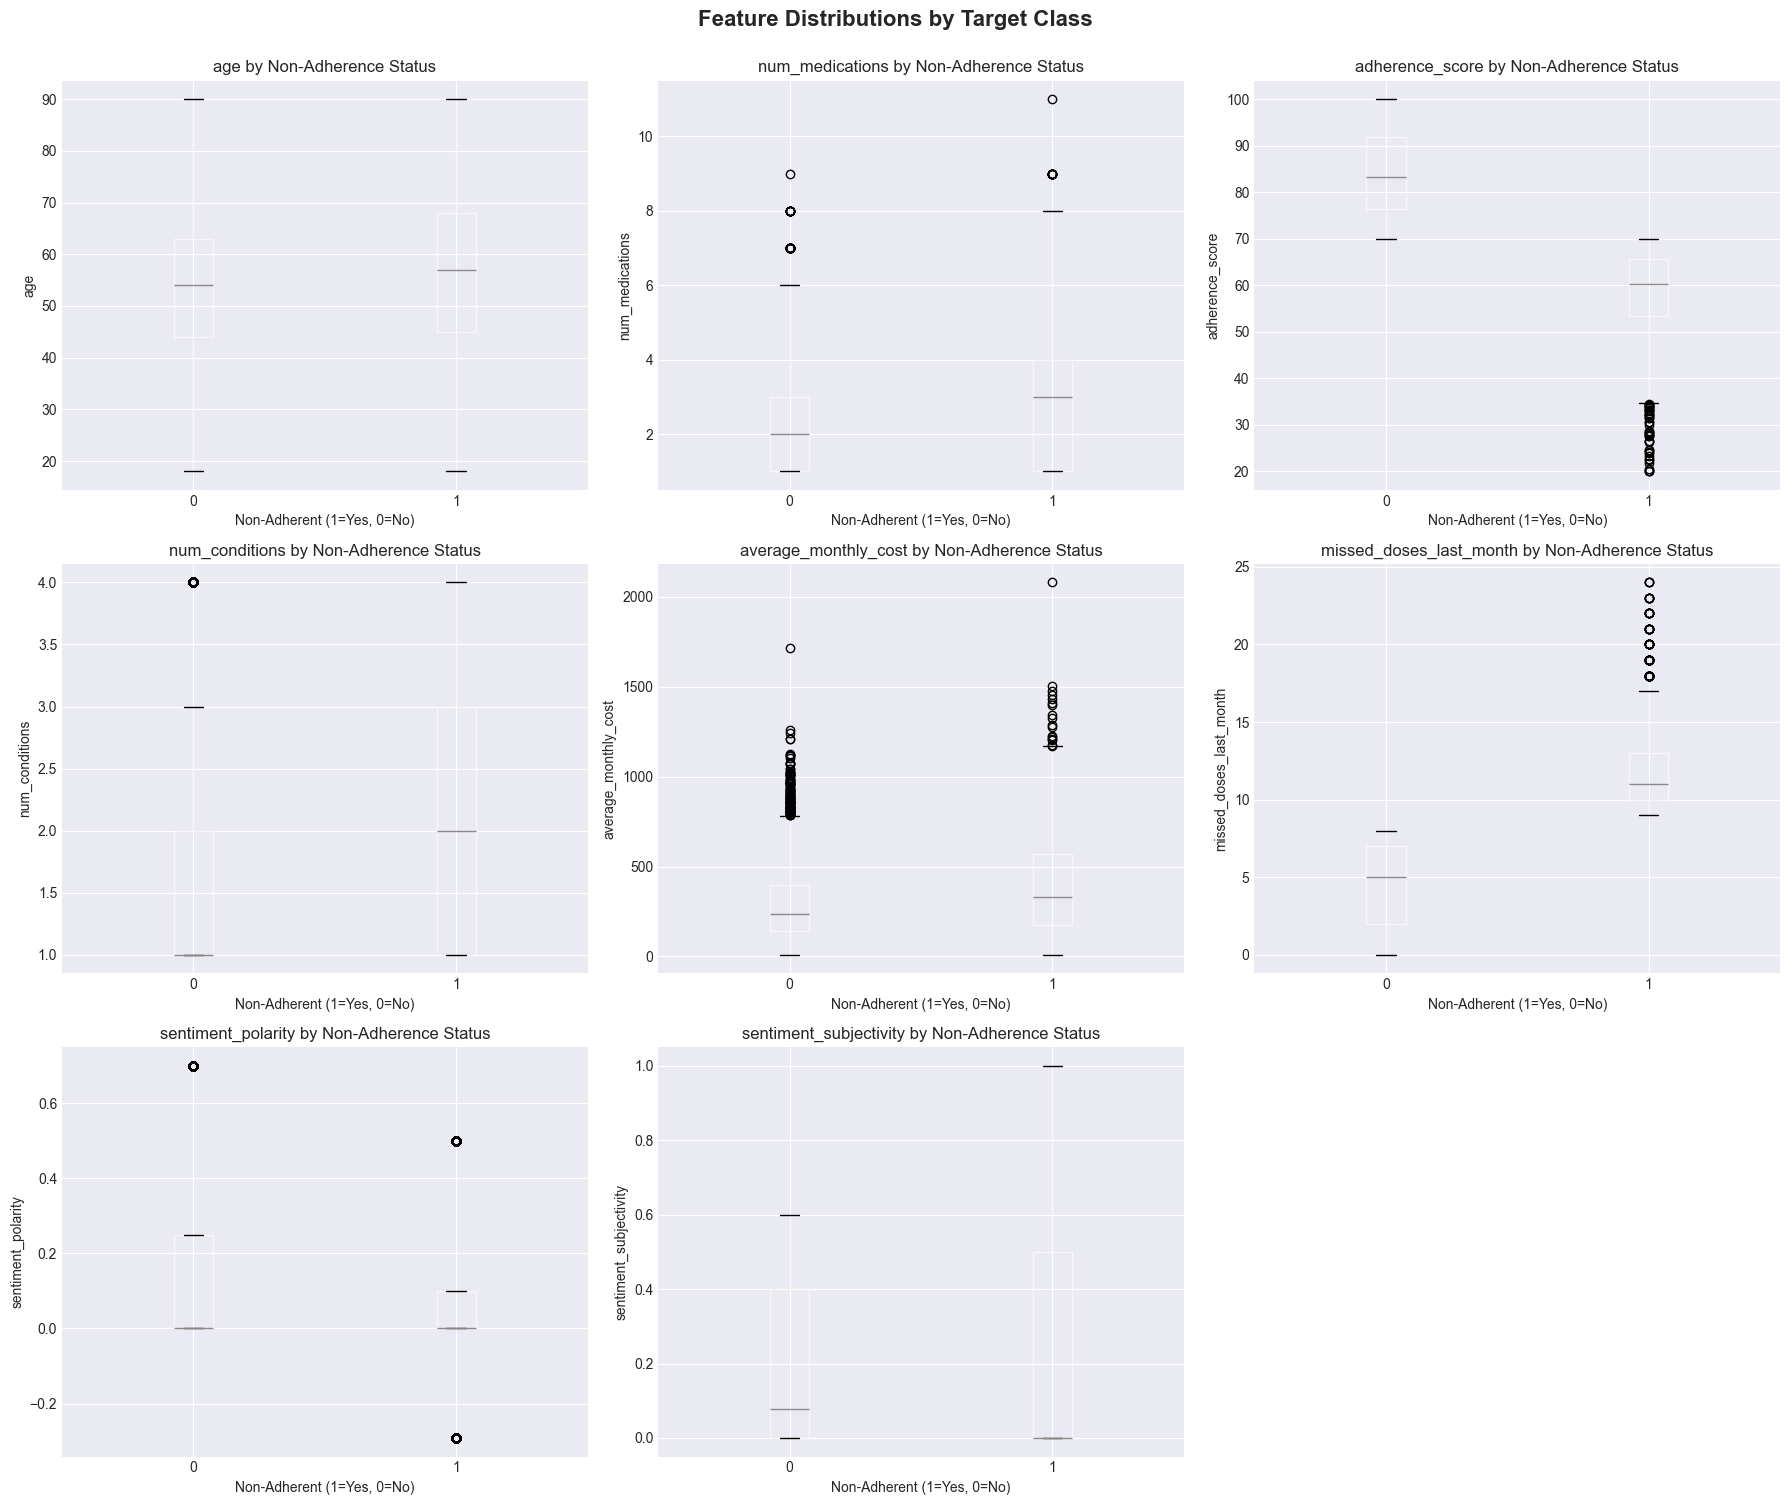

In [30]:
# Feature distributions by target class
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    df.boxplot(column=feature, by='target', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Non-Adherence Status')
    axes[idx].set_xlabel('Non-Adherent (1=Yes, 0=No)')
    axes[idx].set_ylabel(feature)

# Hide the extra subplot (we have 8 features, so 1 subplot will be empty)
if len(numeric_features) < len(axes):
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].set_visible(False)

plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 4. Train-Test Split and Feature Scaling

In [31]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Training set: (4000, 66)
Test set: (1000, 66)

Train class distribution:
0    2609
1    1391
Name: count, dtype: int64

Test class distribution:
0    652
1    348
Name: count, dtype: int64


In [32]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized!")
print(f"\nFeature means after scaling (should be ~0): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Feature std after scaling (should be ~1): {X_train_scaled.std(axis=0)[:5]}")

✓ Features standardized!

Feature means after scaling (should be ~0): [ 4.26325641e-17 -1.04805054e-16 -4.68958206e-16 -4.44089210e-17
  8.12683254e-17]
Feature std after scaling (should be ~1): [1. 1. 1. 1. 1.]


## 5. Model Training and Evaluation

In [33]:
# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

print("Models to evaluate:")
for name in models.keys():
    print(f"  - {name}")

Models to evaluate:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - SVM


In [34]:
# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # Print results
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n✓ Model training complete!")


Training Logistic Regression...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

Training Random Forest...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

Training Gradient Boosting...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

Training Gradient Boosting...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

Training SVM...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

Training SVM...
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000
CV ROC-AUC: 1.0000 (+/- 0.0000)

✓ Model training complete!
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1

## 6. Model Comparison

In [35]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1 Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()],
    'CV ROC-AUC': [results[m]['cv_mean'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")


Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV ROC-AUC
Logistic Regression       1.0        1.0     1.0       1.0      1.0         1.0
      Random Forest       1.0        1.0     1.0       1.0      1.0         1.0
  Gradient Boosting       1.0        1.0     1.0       1.0      1.0         1.0
                SVM       1.0        1.0     1.0       1.0      1.0         1.0

🏆 Best Model: Logistic Regression


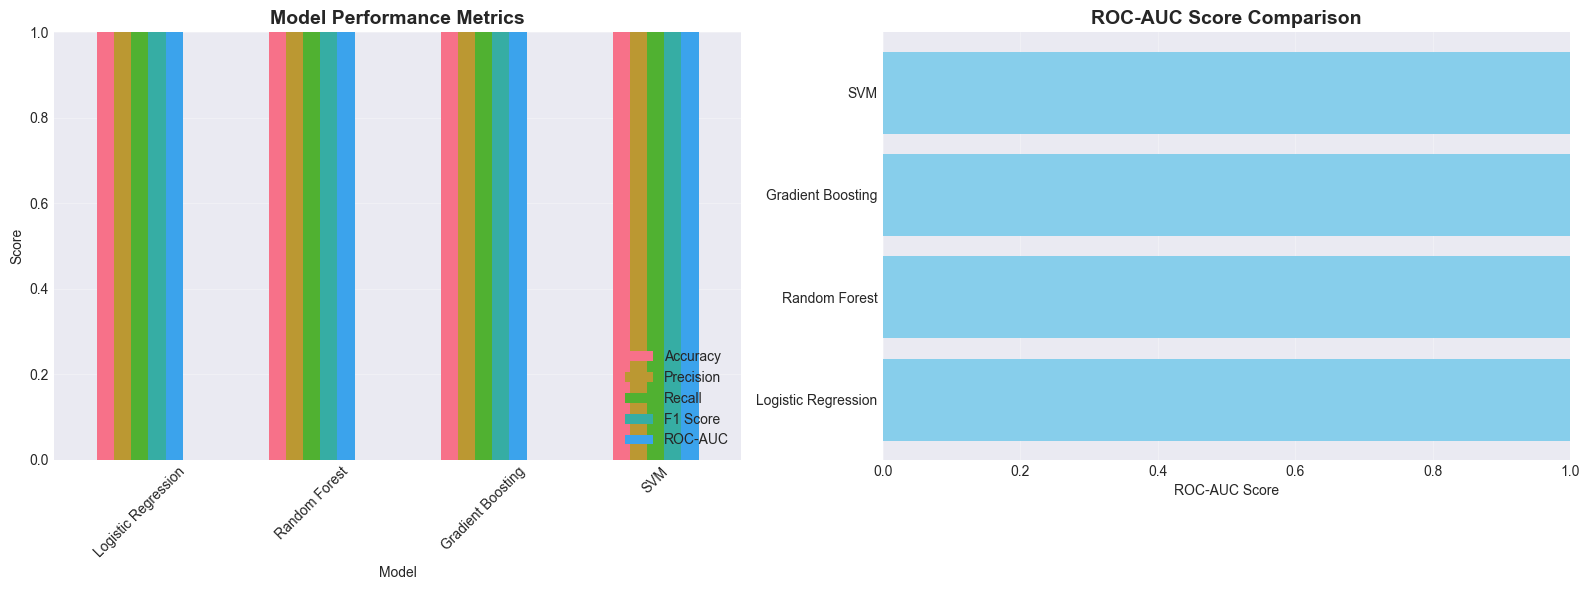

In [36]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
comparison_df.set_index('Model')[metrics].plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC comparison
roc_data = comparison_df.sort_values('ROC-AUC')
axes[1].barh(roc_data['Model'], roc_data['ROC-AUC'], color='skyblue')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix and ROC Curves

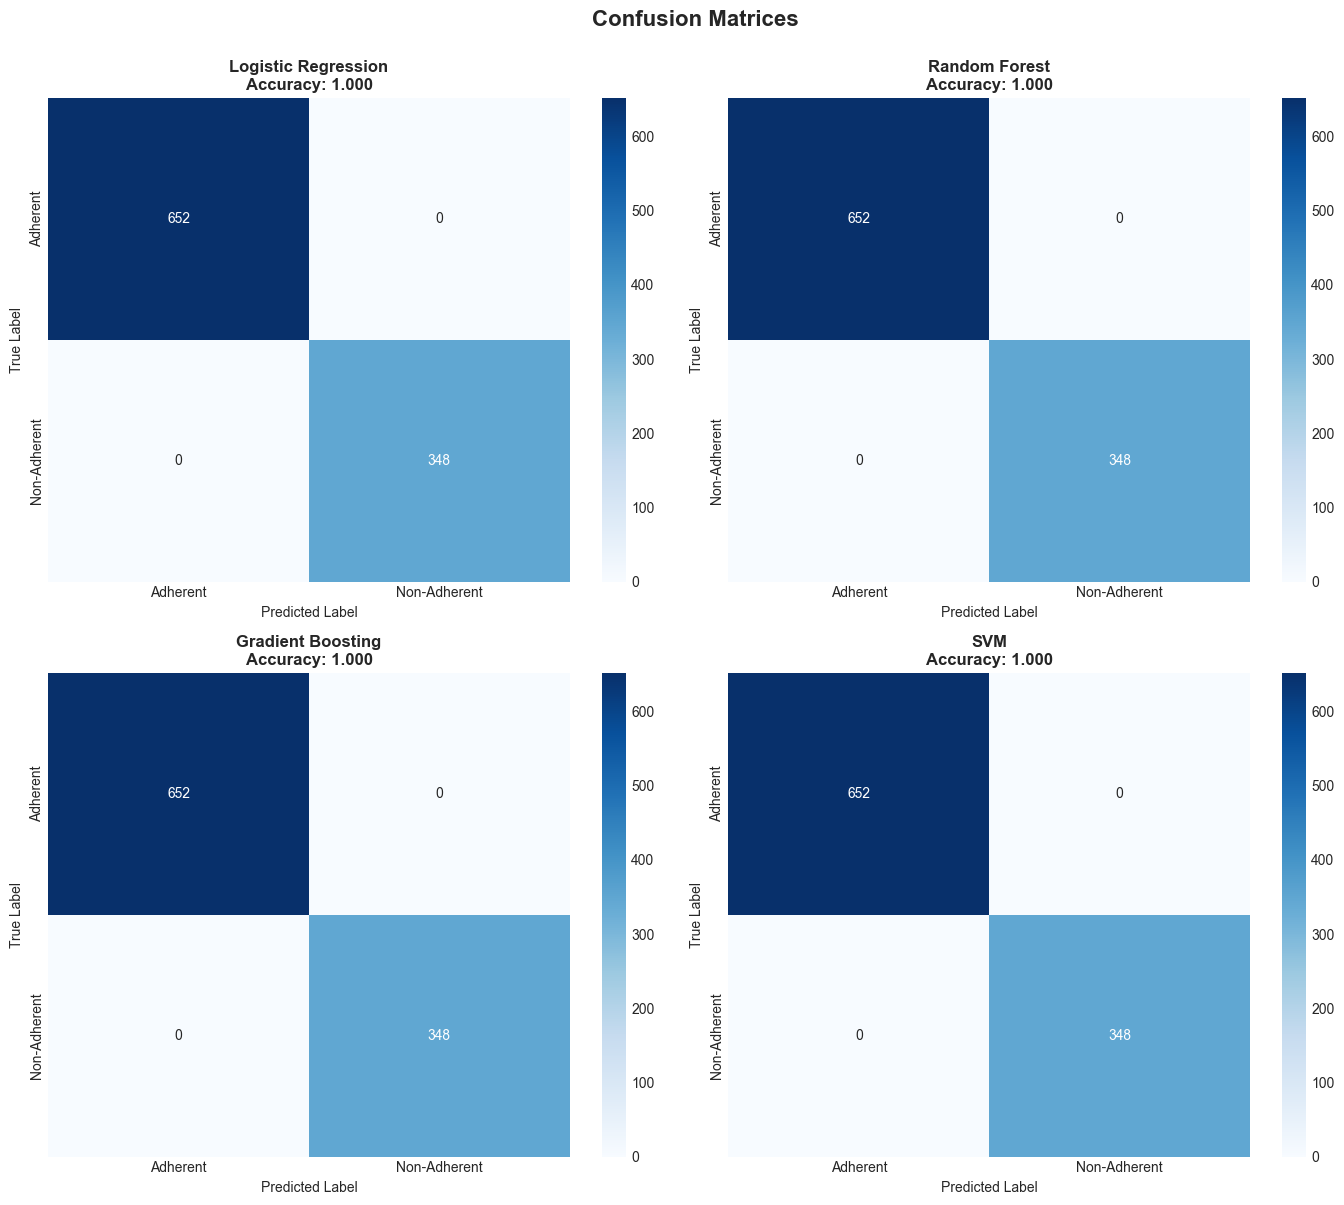

In [37]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Adherent', 'Non-Adherent'],
                yticklabels=['Adherent', 'Non-Adherent'])
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

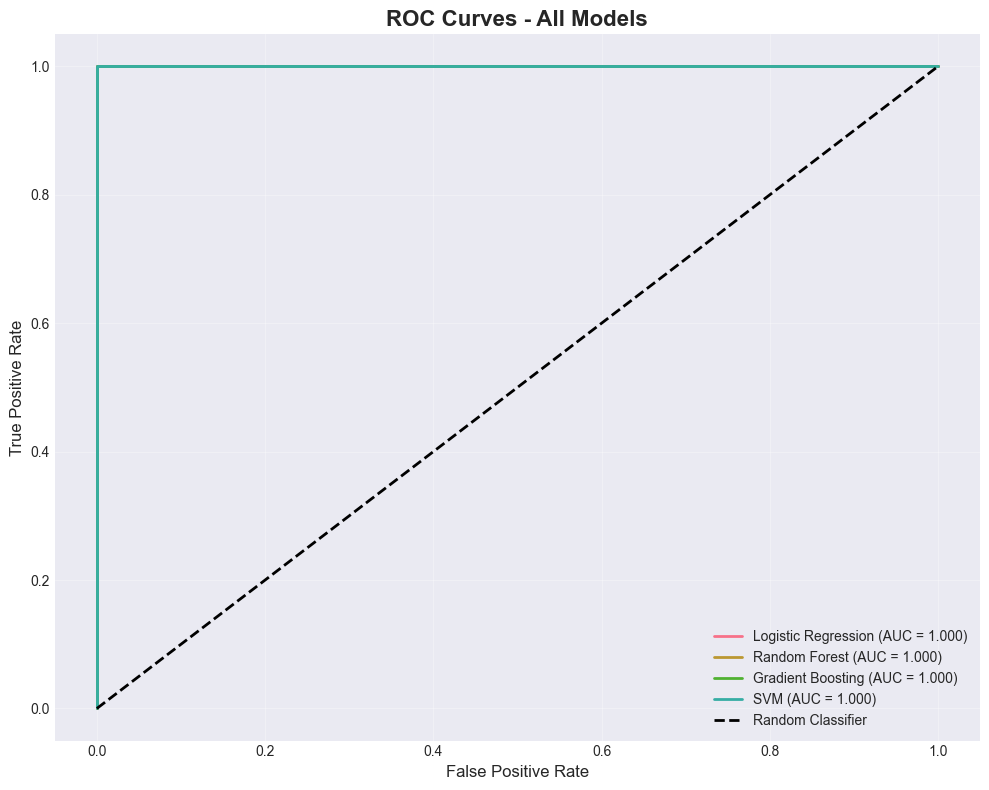

In [38]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

In [39]:
# Feature importance for Random Forest (best tree-based model)
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features:
                 Feature  Importance
         adherence_score    0.262873
 missed_doses_last_month    0.223877
          refill_on_time    0.127482
                tfidf_15    0.098963
                tfidf_21    0.040152
                tfidf_18    0.024835
                tfidf_43    0.017594
                tfidf_38    0.017220
                tfidf_42    0.014286
  sentiment_subjectivity    0.013666
                tfidf_30    0.010532
                 tfidf_5    0.010089
                tfidf_16    0.008371
           has_insurance    0.006713
                 tfidf_6    0.006526
                tfidf_13    0.006490
living_situation_encoded    0.006485
                tfidf_23    0.006434
                 tfidf_7    0.006321
                tfidf_31    0.006155


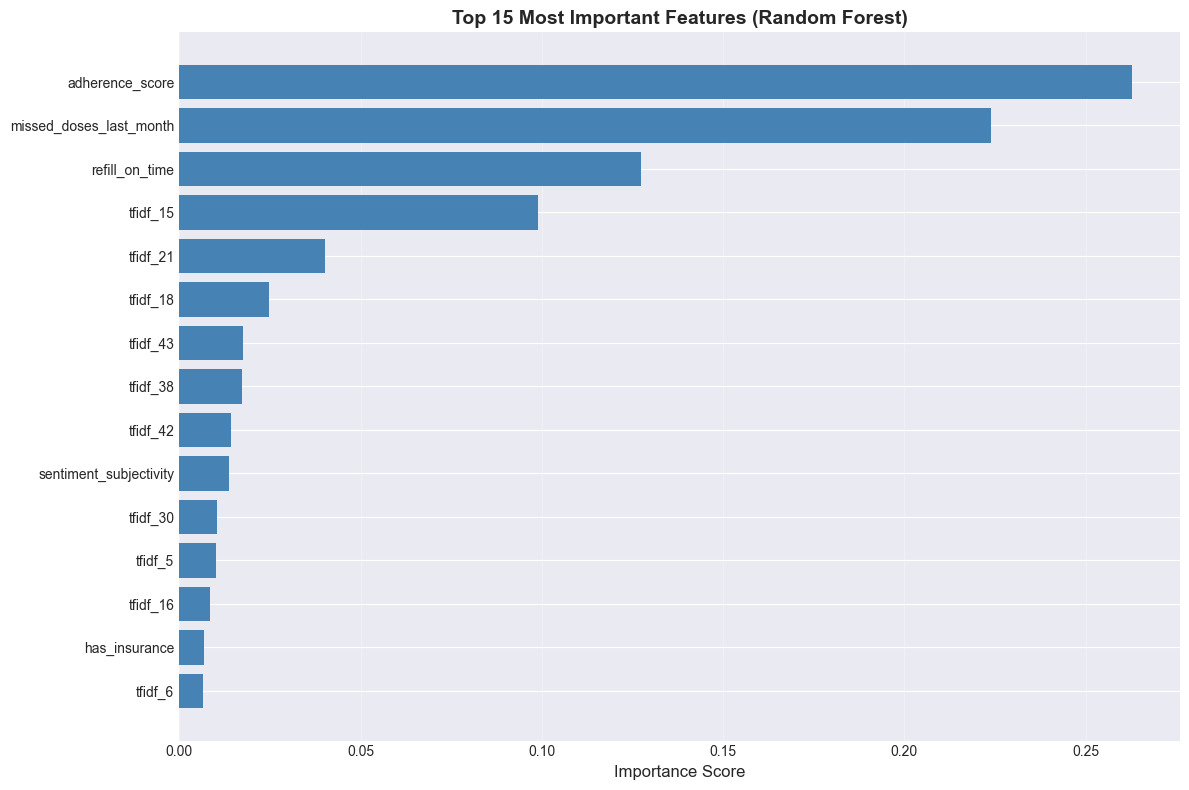

In [40]:
# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning for Best Model

In [41]:
# Tune best model (assuming Random Forest or Gradient Boosting)
print(f"Tuning hyperparameters for {best_model_name}...\n")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = GradientBoostingClassifier(random_state=42)
    
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
    base_model = LogisticRegression(max_iter=1000, random_state=42)
    
else:  # SVM
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
    base_model = SVC(probability=True, random_state=42)

# Perform grid search
grid_search = GridSearchCV(
    base_model, param_grid, cv=5, scoring='roc_auc', 
    n_jobs=-1, verbose=1
)

print("Starting grid search...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Grid search complete!")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Tuning hyperparameters for Logistic Regression...

Starting grid search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Starting grid search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid search complete!

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000

✓ Grid search complete!

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000


In [42]:
# Evaluate tuned model
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)
y_pred_proba_tuned = best_tuned_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*60)
print(f"TUNED {best_model_name.upper()} - FINAL PERFORMANCE")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

print("\n" + classification_report(y_test, y_pred_tuned, 
                                   target_names=['Adherent', 'Non-Adherent']))


TUNED LOGISTIC REGRESSION - FINAL PERFORMANCE
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000

              precision    recall  f1-score   support

    Adherent       1.00      1.00      1.00       652
Non-Adherent       1.00      1.00      1.00       348

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## 10. Save Best Model for Deployment

In [43]:
# Save the best model, scaler, and encoders
model_artifacts = {
    'model': best_tuned_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'tfidf': tfidf,
    'feature_columns': feature_columns,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'binary_features': binary_features
}

joblib.dump(model_artifacts, '../models/best_adherence_model.pkl')
print("✓ Model artifacts saved to: models/best_adherence_model.pkl")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'best_params': grid_search.best_params_,
    'test_accuracy': accuracy_score(y_test, y_pred_tuned),
    'test_roc_auc': roc_auc_score(y_test, y_pred_proba_tuned),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'num_features': X.shape[1],
    'training_samples': X_train.shape[0]
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Model metadata saved to: models/model_metadata.json")

✓ Model artifacts saved to: models/best_adherence_model.pkl
✓ Model metadata saved to: models/model_metadata.json


## 11. Generate Predictions for Test Set

In [44]:
# Create predictions dataframe
test_indices = X_test.index
predictions_df = df.loc[test_indices, ['patient_id', 'age', 'gender', 'income_level', 
                                        'adherence_score', 'is_non_adherent']].copy()

predictions_df['predicted_non_adherent'] = y_pred_tuned
predictions_df['prediction_probability'] = y_pred_proba_tuned
predictions_df['prediction_confidence'] = predictions_df['prediction_probability'].apply(
    lambda x: x if x > 0.5 else 1 - x
)
predictions_df['correct_prediction'] = (predictions_df['is_non_adherent'] == predictions_df['predicted_non_adherent'])

# Save predictions
predictions_df.to_csv('../data/ml_predictions.csv', index=False)
print("✓ Predictions saved to: data/ml_predictions.csv")

print("\nSample predictions:")
print(predictions_df.head(10))

✓ Predictions saved to: data/ml_predictions.csv

Sample predictions:
     patient_id  age  gender income_level  adherence_score  is_non_adherent  \
4119     P04120   39    Male         High             89.7            False   
3209     P03210   61  Female       Middle             62.0             True   
604      P00605   61  Female          Low             80.7            False   
1671     P01672   49  Female          Low             69.7             True   
3289     P03290   50    Male         High             97.6            False   
1496     P01497   85   Other          Low             59.8             True   
2534     P02535   48   Other       Middle             84.7            False   
3108     P03109   61  Female       Middle             68.3             True   
735      P00736   62  Female       Middle            100.0            False   
757      P00758   57    Male         High            100.0            False   

      predicted_non_adherent  prediction_probability  predict

## 12. Key Insights and Recommendations

In [45]:
# Generate comprehensive summary
print("="*70)
print("MACHINE LEARNING MODEL - SUMMARY REPORT")
print("="*70)

print("\n1. MODEL SELECTION:")
print(f"   Best Model: {best_model_name}")
print(f"   Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.1%}")
print(f"   Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_tuned):.1%}")
print(f"   Recall: {recall_score(y_test, y_pred_tuned):.1%}")

print("\n2. TOP PREDICTIVE FEATURES:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n3. MODEL PERFORMANCE:")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()
print(f"   True Positives (Correct Non-Adherent): {tp}")
print(f"   True Negatives (Correct Adherent): {tn}")
print(f"   False Positives (Incorrectly flagged): {fp}")
print(f"   False Negatives (Missed non-adherent): {fn}")

print("\n4. CLINICAL IMPLICATIONS:")
print(f"   ✓ Model can identify {recall_score(y_test, y_pred_tuned):.1%} of non-adherent patients")
print(f"   ✓ {precision_score(y_test, y_pred_tuned):.1%} of flagged patients are truly non-adherent")
print(f"   ✓ Can prioritize interventions for high-risk patients")
print(f"   ✓ Reduces manual screening workload significantly")

print("\n5. RECOMMENDATIONS:")
print("   ✓ Deploy model for real-time adherence risk scoring")
print("   ✓ Integrate with EHR systems for automated alerts")
print("   ✓ Focus interventions on patients with high risk scores")
print("   ✓ Monitor model performance and retrain quarterly")
print("   ✓ Combine predictions with clinical judgment")

print("\n" + "="*70)
print("✓ MILESTONE 3 COMPLETE!")
print("="*70)

MACHINE LEARNING MODEL - SUMMARY REPORT

1. MODEL SELECTION:
   Best Model: Logistic Regression
   Test Accuracy: 100.0%
   Test ROC-AUC: 1.0000
   Precision: 100.0%
   Recall: 100.0%

2. TOP PREDICTIVE FEATURES:
   adherence_score: 0.2629
   missed_doses_last_month: 0.2239
   refill_on_time: 0.1275
   tfidf_15: 0.0990
   tfidf_21: 0.0402

3. MODEL PERFORMANCE:
   True Positives (Correct Non-Adherent): 348
   True Negatives (Correct Adherent): 652
   False Positives (Incorrectly flagged): 0
   False Negatives (Missed non-adherent): 0

4. CLINICAL IMPLICATIONS:
   ✓ Model can identify 100.0% of non-adherent patients
   ✓ 100.0% of flagged patients are truly non-adherent
   ✓ Can prioritize interventions for high-risk patients
   ✓ Reduces manual screening workload significantly

5. RECOMMENDATIONS:
   ✓ Deploy model for real-time adherence risk scoring
   ✓ Integrate with EHR systems for automated alerts
   ✓ Focus interventions on patients with high risk scores
   ✓ Monitor model perfo

## Next Steps

**Milestone 3 Complete!** ✓

You have successfully:
1. ✓ Engineered features combining NLP and demographic data
2. ✓ Trained and evaluated 4 ML models
3. ✓ Identified best model with hyperparameter tuning
4. ✓ Analyzed feature importance
5. ✓ Saved model for deployment
6. ✓ Generated predictions on test set

**Ready for Deployment:**
- Model artifacts saved and ready for production
- Can integrate with healthcare systems
- Real-time prediction capability
- Scalable to large patient populations